# Retail Markdown Optimization

### STEP 1 : PROBLEM STATEMENT

##### --- To decide the best time and best discount percentage for retail products to maximize sales and profit while minimizing losses.

#### The goal is to:

#### >> Increase sales

#### >> Maximize profit

#### >> Avoid over-discounting and under-discounting

### STEP 2 : IMPORT LIBARIESS 

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### STEP 3 : DATA COLLECTION

In [109]:
data = pd.read_csv("SYNTHETIC Markdown Dataset.csv")
data.head()


,Product_ID,Category,Brand,Season,Product_Name,Original_Price,Competitor_Price,Seasonality_Factor,Markdown_1,Markdown_2,...,Historical_Sales,Sales_After_M1,Sales_After_M2,Sales_After_M3,Sales_After_M4,Stock_Level,Promotion_Type,Customer Ratings,Return Rate,Optimal Discount
0,1,Skincare,BrandA,Summer,Sunscreen,70.39,70.98,1.71,0.31,0.49,...,344,404,540,650,979,183,In-Store,4.9,1.97,0.36
1,2,Skincare,BrandB,Rainy,Eye Cream,55.35,56.58,0.85,0.39,0.21,...,98,107,116,118,143,142,Online,4.0,2.57,0.29
2,3,Skincare,BrandA,Spring,Face Mist,26.16,28.54,1.03,0.17,0.43,...,72,72,87,84,84,112,Social Media,2.3,4.64,0.33
3,4,Bodycare,BrandD,Winter,Shower Gel,99.34,98.57,1.91,0.20,0.21,...,243,281,316,361,539,57,In-Store,4.9,1.42,0.25
4,5,Skincare,BrandA,Winter,Peeling Gel,60.33,61.05,1.65,0.14,0.20,...,251,289,325,402,534,125,In-Store,4.6,1.36,0.23


### STEP 4 : DATA PREPROCESSING

In [110]:
data.describe()

,Product_ID,Original_Price,Competitor_Price,Seasonality_Factor,Markdown_1,Markdown_2,Markdown_3,Markdown_4,Historical_Sales,Sales_After_M1,Sales_After_M2,Sales_After_M3,Sales_After_M4,Stock_Level,Customer Ratings,Return Rate,Optimal Discount
count,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000
mean,21705.645051,52.659917,53.648610,1.328372,0.250620,0.350107,0.199834,0.400097,171.893554,201.142171,250.353897,286.513623,370.565303,124.854469,4.290862,2.203713,0.300373
std,12526.600860,27.515733,27.542159,0.466122,0.086428,0.086604,0.057907,0.057977,88.500750,111.765796,152.876420,184.139572,258.253190,43.211560,0.810869,1.258030,0.036854
min,1.000000,5.000000,4.100000,0.500000,0.100000,0.200000,0.100000,0.300000,26.000000,26.000000,25.000000,26.000000,25.000000,50.000000,2.000000,1.000000,0.180000
25%,10863.250000,28.820000,29.800000,0.900000,0.180000,0.280000,0.150000,0.350000,101.000000,113.000000,128.000000,137.000000,152.000000,88.000000,4.000000,1.360000,0.280000
50%,21705.500000,52.840000,53.835000,1.500000,0.250000,0.350000,0.200000,0.400000,154.000000,175.000000,210.000000,236.000000,299.000000,124.000000,4.600000,1.720000,0.300000
75%,32550.750000,76.630000,77.597500,1.750000,0.330000,0.430000,0.250000,0.450000,233.000000,276.000000,357.000000,415.000000,555.000000,162.000000,4.800000,2.600000,0.320000
max,43400.000000,100.000000,102.960000,2.000000,0.400000,0.500000,0.300000,0.500000,416.000000,579.000000,844.000000,1114.000000,1535.000000,200.000000,5.000000,6.000000,0.420000


In [111]:
data.shape

(43750, 22)

In [112]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43750 entries, 0 to 43749
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Product_ID          43750 non-null  int64  
 1   Category            43750 non-null  object 
 2   Brand               43750 non-null  object 
 3   Season              43750 non-null  object 
 4   Product_Name        43750 non-null  object 
 5   Original_Price      43750 non-null  float64
 6   Competitor_Price    43750 non-null  float64
 7   Seasonality_Factor  43750 non-null  float64
 8   Markdown_1          43750 non-null  float64
 9   Markdown_2          43750 non-null  float64
 10  Markdown_3          43750 non-null  float64
 11  Markdown_4          43750 non-null  float64
 12  Historical_Sales    43750 non-null  int64  
 13  Sales_After_M1      43750 non-null  int64  
 14  Sales_After_M2      43750 non-null  int64  
 15  Sales_After_M3      43750 non-null  int64  
 16  Sale

In [113]:
data.columns

Index(['Product_ID', 'Category', 'Brand', 'Season', 'Product_Name',
       'Original_Price', 'Competitor_Price', 'Seasonality_Factor',
       'Markdown_1', 'Markdown_2', 'Markdown_3', 'Markdown_4',
       'Historical_Sales', 'Sales_After_M1', 'Sales_After_M2',
       'Sales_After_M3', 'Sales_After_M4', 'Stock_Level', 'Promotion_Type',
       'Customer Ratings', 'Return Rate', 'Optimal Discount'],
      dtype='object')

In [114]:
data.isnull().sum()

Product_ID            0
Category              0
Brand                 0
Season                0
Product_Name          0
Original_Price        0
Competitor_Price      0
Seasonality_Factor    0
Markdown_1            0
Markdown_2            0
Markdown_3            0
Markdown_4            0
Historical_Sales      0
Sales_After_M1        0
Sales_After_M2        0
Sales_After_M3        0
Sales_After_M4        0
Stock_Level           0
Promotion_Type        0
Customer Ratings      0
Return Rate           0
Optimal Discount      0
dtype: int64

In [115]:
data.duplicated().sum()

np.int64(350)

In [116]:
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

In [117]:
data.shape

(43400, 22)

### STEP 5 : feature engineering

In [118]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

categorical_columns = (
    'Category',
    'Brand',
    'Season',
    'Promotion_Type',
    'Product_Name',
)

for col in categorical_columns:
    data[col] = le.fit_transform(data[col])

### STEP 6 : feature Selection

In [119]:
X = data.drop(['Optimal Discount', 'Product_ID'], axis=1)
y = data['Optimal Discount']

In [120]:
# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

### STEP 7 : FEATURE SCALING

### minmax scaler


In [121]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


### STEP 8 : TRAIN-TEST SPLIT

In [122]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [123]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on training data
X_test_scaled = scaler.transform(X_test)         # transform test data


### STEP 9 : MODEL SELECTION


#### RANDOM FOREST REGRESSION

In [105]:
from sklearn.ensemble import RandomForestRegressor

RF_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

RF_model.fit(X_train_scaled, y_train)


RandomForestRegressor(random_state=42)

### linear regression

In [73]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Accuracy

In [74]:
from sklearn.metrics import r2_score
LR_Accuracy = r2_score(y_test, model.predict(X_test))
LR_Accuracy

0.9930265749233118

###  decission tree regression

In [ ]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(X_train, y_train)
from sklearn.metrics import r2_score
DTR_Accuracy=round(r2_score(y_test, model.predict(X_test)) * 100)
DTR_Accuracy

96

### support vector regression

In [ ]:
from sklearn.svm import SVR
model = SVR()
model.fit(X_train, y_train)
from sklearn.metrics import r2_score
SVR_Accuracy=round(r2_score(y_test, model.predict(X_test)) * 100)
SVR_Accuracy

10

### random forest regressor with estimate

In [ ]:
from sklearn.ensemble import RandomForestRegressor
RF_model = RandomForestRegressor(n_estimators=10)
RF_model.fit(X_train, y_train)
from sklearn.metrics import r2_score
RFR_Accuracy=round(r2_score(y_test, RF_model.predict(X_test)) * 100)
RFR_Accuracy

98

In [79]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = RF_model.predict(X_test_scaled)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 0.045924769585253454
R2 Score: -0.9926969952836315


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


C:\Users\Admin\AppData\Local\Temp\ipykernel_21096\3742275944.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Accuracy, y=models, palette='pastel')


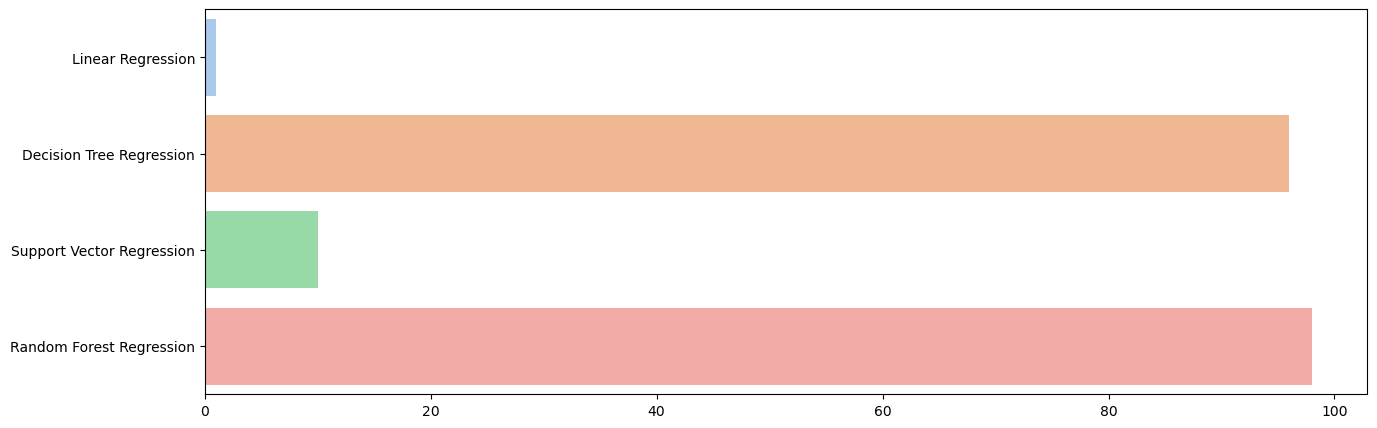

In [128]:
models = ["Linear Regression", "Decision Tree Regression", "Support Vector Regression", "Random Forest Regression"]
Accuracy = [LR_Accuracy, DTR_Accuracy, SVR_Accuracy, RFR_Accuracy]
plt.figure(figsize=(15, 5))
sns.barplot(x=Accuracy, y=models, palette='pastel')
plt.show()

### STEP 10: MODEL PREDICTION

In [131]:
import pandas as pd
import pickle

RF_model = pickle.load(open("RF_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))
feature_columns = pickle.load(open("feature_columns.pkl", "rb"))
input_data = {col: 0 for col in feature_columns}

input_data.update({
    'Original_Price': 499,
    'Competitor_Price': 450,
    'Stock_Level': 300,
    'Historical_Sales': 120,
    'Seasonality_Factor': 1.2,
})

input_df = pd.DataFrame([input_data])
input_scaled = scaler.transform(input_df)
prediction = RF_model.predict(input_scaled)

print("✅ Predicted Optimal Discount:", prediction[0])


✅ Predicted Optimal Discount: 0.192


### STEP 11: SAVE THE MODEL & SCALERS

In [125]:
import pickle

pickle.dump(RF_model, open("RF_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
